In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import sys
import os
from PIL import Image
import matplotlib.pyplot as plt

c:\Users\bdsoc\miniconda3\envs\bitblind\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
# To use the pretrained model, you must download TPS-ResNet-BiLSTM-CTC.pth from here and move into a saved_models/ directory.
# https://www.dropbox.com/scl/fo/txf1v9m8p6xs8lq0yo0sc/AKjBi0yrQETefIvV_fXwXfQ?rlkey=j179442w75t7s907w6qpwhaeu&e=1&dl=0

In [3]:
# Importing the OCR model from deep-text-recognition-benchmark

# Get the absolute path to the submodule
submodule_path = os.path.join(os.getcwd(), "deep-text-recognition-benchmark")
sys.path.append(submodule_path)

from model import Model
from utils import CTCLabelConverter

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Match pretrained configuration exactly
class Opt:
    Transformation = 'TPS'
    FeatureExtraction = 'ResNet'
    SequenceModeling = 'BiLSTM'
    Prediction = 'CTC'
    num_fiducial = 20
    imgH = 32
    imgW = 100
    input_channel = 1
    output_channel = 512
    hidden_size = 256
    character = '0123456789abcdefghijklmnopqrstuvwxyz'
    batch_max_length = 25

opt = Opt()

converter = CTCLabelConverter(opt.character)
num_class = len(converter.character)
opt.num_class = num_class

model = Model(opt)
model = torch.nn.DataParallel(model).to(device)

model.load_state_dict(
    torch.load('saved_models/TPS-ResNet-BiLSTM-CTC.pth', map_location=device)
)

model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [5]:
def preprocess(img_path, device):
    transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((32, 100)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])  # IMPORTANT
    ])
    
    img = Image.open(img_path).convert("RGB")
    img = transform(img)
    img = img.unsqueeze(0)  # batch dimension
    
    return img.to(device)

In [6]:
def infer(model, converter, img_tensor):
    with torch.no_grad():
        preds = model(img_tensor, text=None)

    # preds: [B, T, C] → convert to [T, B, C]
    preds = preds.permute(1, 0, 2).log_softmax(2)

    # Get max index
    _, preds_index = preds.max(2)
    preds_index = preds_index.permute(1, 0).contiguous()  # [B, T]

    preds_size = torch.IntTensor([preds.size(0)])

    text = converter.decode(preds_index, preds_size)
    return text

In [7]:
def pgd_ctc_untargeted(
    model,
    converter,
    img,
    gt_text,
    epsilon=0.06,
    alpha=0.01,
    steps=30
):
    """
    Untargeted PGD attack that maximizes CTC loss.
    """

    model.train()

    original = img.clone().detach().to(device)
    adv = original.clone()

    # Encode ground truth text
    text_encoded, length = converter.encode([gt_text])
    text_encoded = text_encoded.to(device)
    length = length.to(device)

    for _ in range(steps):

        adv.requires_grad = True

        preds = model(adv, text=None)         # [B,T,C]
        preds = preds.permute(1,0,2)          # [T,B,C]
        preds_log_softmax = preds.log_softmax(2)

        preds_size = torch.IntTensor([preds.size(0)]).to(device)

        loss = F.ctc_loss(
            preds_log_softmax,
            text_encoded,
            preds_size,
            length,
            blank=0
        )

        # We want to MAXIMIZE CTC loss
        model.zero_grad()
        loss.backward()

        adv = adv + alpha * adv.grad.sign()

        # Project into epsilon-ball
        eta = torch.clamp(adv - original, -epsilon, epsilon)
        adv = torch.clamp(original + eta, -1, 1).detach()

    return adv

In [8]:
def show_comparison_dual(
    preprocessed_orig,  # tensor [1,1,H,W] normalized [-1,1]
    preprocessed_adv,   # tensor [1,1,H,W] normalized [-1,1]
    orig_pil,           # PIL.Image, full-res original
    adv_pil,            # PIL.Image, full-res adversarial
    scale_pre=20,       # scale factor for preprocessed perturbation
    scale_full=20       # scale factor for full-res perturbation
):
    # -------- Top row: preprocessed --------
    orig_pre = preprocessed_orig.detach().cpu().squeeze(0).squeeze(0).numpy()
    adv_pre  = preprocessed_adv.detach().cpu().squeeze(0).squeeze(0).numpy()
    delta_pre = (adv_pre - orig_pre) * scale_pre

    # -------- Bottom row: full-res --------
    # Convert PIL to tensor [C,H,W] in [0,1]
    to_tensor = transforms.ToTensor()
    orig_full = to_tensor(orig_pil).cpu()
    adv_full  = to_tensor(adv_pil).cpu()
    delta_full = (adv_full - orig_full) * scale_full

    # Convert to numpy with shape [H,W,C] for imshow
    orig_full_np = orig_full.permute(1,2,0).numpy()
    adv_full_np  = adv_full.permute(1,2,0).numpy()
    delta_full_np = delta_full.permute(1,2,0).numpy()
    delta_full_np_clipped = np.clip(delta_full_np, 0, 1)

    # -------- Plot --------
    fig, axes = plt.subplots(2,3, figsize=(15,8))

    # Top row: preprocessed
    axes[0,0].imshow(orig_pre, cmap='gray')
    axes[0,0].set_title("Preprocessed Original")
    axes[0,0].axis("off")

    axes[0,1].imshow(adv_pre, cmap='gray')
    axes[0,1].set_title("Preprocessed Adversarial")
    axes[0,1].axis("off")

    axes[0,2].imshow(delta_pre, cmap='gray')
    axes[0,2].set_title(f"Preprocessed Perturbation x{scale_pre}")
    axes[0,2].axis("off")

    # Bottom row: full-res
    axes[1,0].imshow(orig_full_np)
    axes[1,0].set_title("Original Full-Res")
    axes[1,0].axis("off")

    axes[1,1].imshow(adv_full_np)
    axes[1,1].set_title("Adversarial Full-Res")
    axes[1,1].axis("off")

    axes[1,2].imshow(delta_full_np_clipped)
    axes[1,2].set_title(f"Full-Res Perturbation x{scale_full}")
    axes[1,2].axis("off")

    plt.tight_layout()
    plt.show()

In [9]:
def apply_adversarial_to_original(orig_pil, adv_img, original_img_tensor):
    """
    orig_pil: original PIL.Image
    adv_img: adversarial image from PGD ([1,1,32,100], normalized [-1,1])
    original_img_tensor: preprocessed tensor of original image ([1,1,32,100])
    """
    # 1. Compute perturbation in normalized [-1,1]
    delta = adv_img - original_img_tensor  # shape [1,1,32,100]

    # 2. Upsample to original size
    H, W = orig_pil.size[1], orig_pil.size[0]  # PIL: size=(W,H)
    delta_upsampled = F.interpolate(delta, size=(H,W), mode='bilinear', align_corners=False)

    # 3. Convert grayscale perturbation to RGB
    delta_rgb = delta_upsampled.repeat(1,3,1,1)  # [1,3,H,W]

    # 4. Convert original PIL to tensor [0,1]
    orig_tensor = transforms.ToTensor()(orig_pil).unsqueeze(0)  # [1,3,H,W]

    # 5. Apply perturbation (rescale from [-1,1] to small pixel change)
    # Assuming original preprocessing used mean=0.5,std=0.5 → reverse normalize
    delta_pixel = delta_rgb * 0.5  # map [-1,1] perturbation to pixel range ~[-0.5,0.5]
    adv_full_res = orig_tensor + delta_pixel

    # 6. Clip to [0,1]
    adv_full_res = torch.clamp(adv_full_res, 0, 1)

    # 7. Convert back to PIL
    adv_pil = transforms.ToPILImage()(adv_full_res.squeeze(0))

    return adv_pil

Original OCR: available
Adversarial OCR: eenaurd


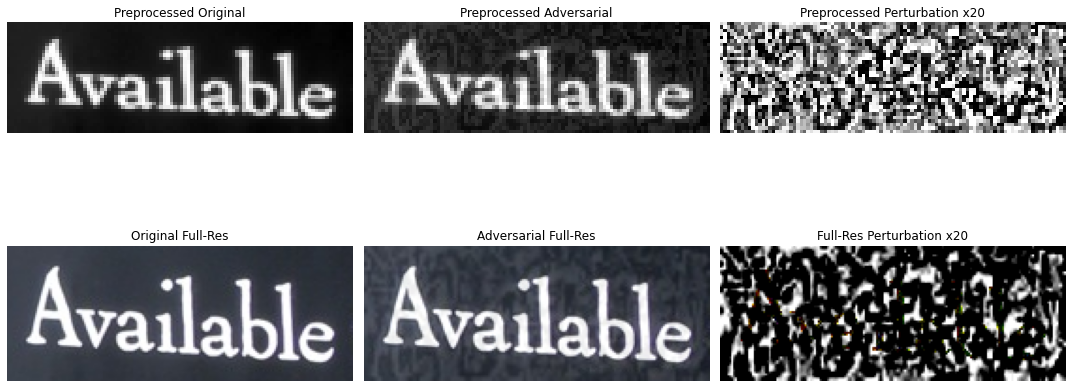

In [11]:
IMAGE_PATH = "deep-text-recognition-benchmark/demo_image/demo_1.png"
OUTPUT_PATH = "sample_adversarial.png"

# Attack parameters
EPSILON = 0.12 # attack budget
ALPHA = 0.01 # gradient step size
STEPS = 90 # number of attack iterations

# Run inference on unaltered image to get the ground truth.
img = preprocess(IMAGE_PATH, device)
gt = infer(model, converter, img)[0]

# Run the attack using Projected Gradident Descent (PGD).
# Uses Connectionist Temporal Classification (CTC) loss to push the model
# away from the correct transcription.
adv_img = pgd_ctc_untargeted(
    model,
    converter,
    img,
    gt_text=str(gt),
    epsilon=EPSILON,
    alpha=ALPHA,
    steps=STEPS
)

# Apply the adversarial perturbation to the original image without being preprocessed
orig_pil = Image.open(IMAGE_PATH).convert("RGB")
adv_pil = apply_adversarial_to_original(orig_pil, adv_img, img)
adv_pil.save(OUTPUT_PATH)

# Test inference with adversarial noise
print("Original OCR:", gt)
print("Adversarial OCR:", infer(model, converter, adv_img)[0])

# Display graphic
show_comparison_dual(img, adv_img, orig_pil, adv_pil)